In [50]:
import pandas as pd
df=pd.read_csv("D:\data analatics\matches.csv")
print(df.columns)
df.isnull().sum()

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='str')


<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_13548\2786283239.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df=pd.read_csv("D:\data analatics\matches.csv")


id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [35]:
df["method"]=df["method"].fillna("Standard") 
df['result_margin'] = df['result_margin'].fillna(0)


In [36]:
missing_city_venues = df[df['city'].isnull()]['venue'].unique()
print( missing_city_venues)

<StringArray>
['Sharjah Cricket Stadium', 'Dubai International Cricket Stadium']
Length: 2, dtype: str


In [37]:
venue_city=(
    df.dropna(subset=['city'])
    .drop_duplicates('venue')
    .set_index('venue')['city']

)
df['city']=df['city'].fillna(df['venue'].map(venue_city))
print(df['city'].isnull().sum())

0


In [38]:

df = df.dropna(subset=['winner'])
df['target_runs']=df['target_runs'].fillna(0)
df['target_overs']=df['target_overs'].fillna(0)
df['player_of_match']=df['player_of_match'].fillna('no Award')

df.isnull().sum()

id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
method             0
umpire1            0
umpire2            0
dtype: int64

In [51]:
df.to_csv("D:\\data analatics\\matches_cleaned.csv", index=False)


In [58]:
df=pd.read_csv("D:\\data analatics\\matches_cleaned.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [59]:
df.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [60]:
df=df.set_index('id',inplace=False)


In [64]:
df['date']=pd.to_datetime(df['date'])
print(df['date'].min())

2008-04-18 00:00:00


In [72]:
#identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

columns_to_skip = ['player_of_match', 'umpire1', 'umpire2']
categorical_cols = categorical_cols.drop(columns_to_skip,errors='ignore')
#identify numerical columns
numerical_cols=df.select_dtypes(include=['number']).columns
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)



Categorical columns: Index(['season', 'city', 'match_type', 'venue', 'team1', 'team2',
       'toss_winner', 'toss_decision', 'winner', 'result', 'super_over',
       'method'],
      dtype='str')
Numerical columns: Index(['result_margin', 'target_runs', 'target_overs'], dtype='str')


C:\Users\HP\AppData\Local\Temp\ipykernel_13548\1635275073.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns



--- Top 10 Players of the Match ---
player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
SP Narine         15
Name: count, dtype: int64


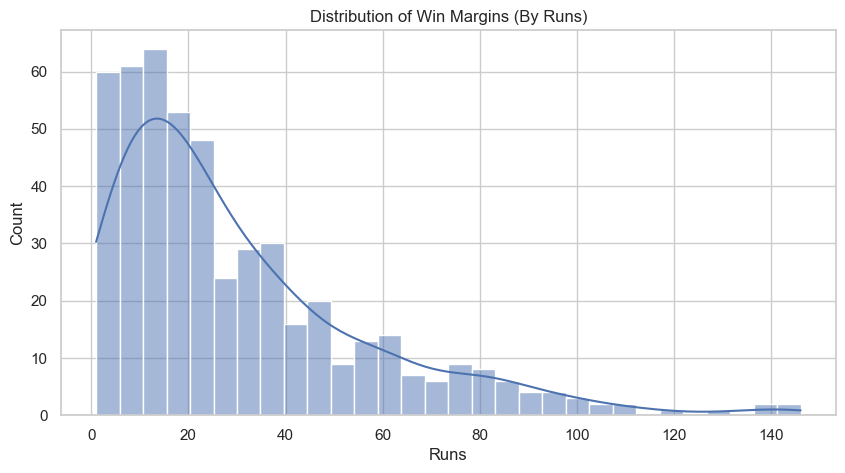

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


print("\n--- Top 10 Players of the Match ---")
print(df['player_of_match'].value_counts().head(10))


plt.figure(figsize=(10, 5))
sns.histplot(df[df['result'] == 'runs']['result_margin'], bins=30, kde=True)
plt.title('Distribution of Win Margins (By Runs)')
plt.xlabel('Runs')
plt.show()

In [78]:
df['toss_winner_is_winner'] = (df['toss_winner'] == df['winner'])

print("\n--- Match Win Percentage by Toss Winners ---")
win_percentage = df['toss_winner_is_winner'].value_counts()*100 /len(df)
print(win_percentage)


--- Match Win Percentage by Toss Winners ---
toss_winner_is_winner
True     50.593607
False    49.406393
Name: count, dtype: float64


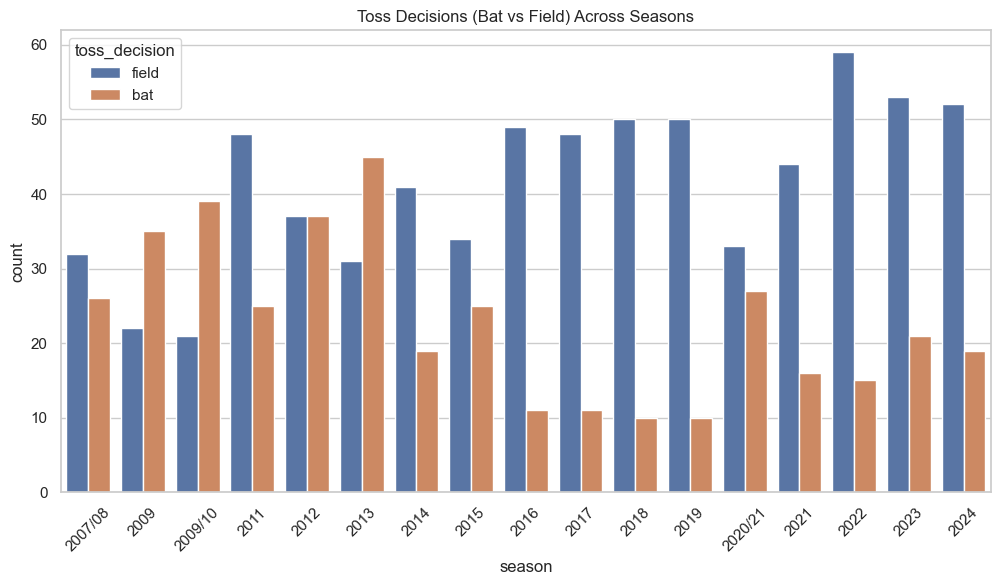

In [82]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='season', hue='toss_decision')
plt.title('Toss Decisions (Bat vs Field) Across Seasons')
plt.xticks(rotation=45)
plt.show()